In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'




In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [5]:
mertz = [144.25,-67.5]

In [6]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [7]:
elevation_ = GEBCO(coarsen_factor=10).ds.elevation
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')


In [8]:
sice = sice.__xarray_dataarray_variable__

In [9]:
data_extent = [138,148,-68.5,-65]
map_extent = [138,148,-68.5,-65]

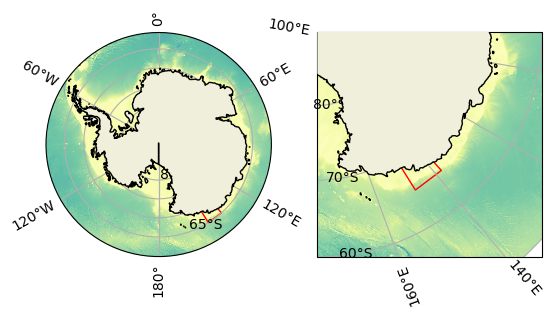

In [10]:
fig, ax = plt.subplots(1,2,subplot_kw={"projection":ccrs.SouthPolarStereo()})
pfns.sp(ax[0],elevation_,sea='Small Southern Ocean')
extent = data_extent
ax[0].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))
pfns.sp(ax[1],elevation_,extent=[90,180,-80,-60])
ax[1].add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [11]:
# crop elevation
elevation = elevation_.sel(latitude = slice(map_extent[2], map_extent[3]), longitude = slice(map_extent[0],map_extent[1]))

In [12]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [13]:
meop=MEOP(extent=data_extent)

In [14]:
meop.load_profiles()

  0%|          | 0/84 [00:00<?, ?it/s]

100%|██████████| 84/84 [02:33<00:00,  1.82s/it]


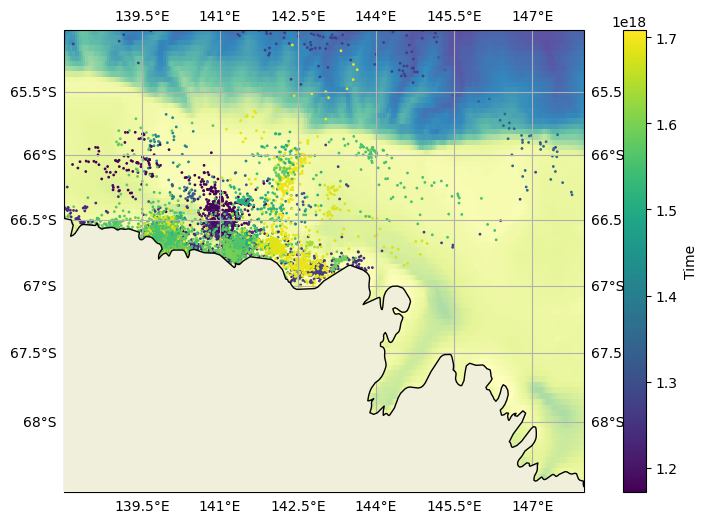

In [15]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax=ax,da=elevation,extent=map_extent)
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [16]:
rg_1 = [142,143,-67.5,-66.5]
rg_2 = [140,141.5,-68.5,-66.5]
rg_3  = [139.5,140,-68.5,-66.5]



In [17]:
meop_1 = MEOP(extent=rg_1)
meop_2 = MEOP(extent=rg_2)
meop_3 = MEOP(extent=rg_3)


In [18]:
meop_1.load_profiles()

 38%|███▊      | 29/77 [00:01<00:02, 20.99it/s]

100%|██████████| 77/77 [00:12<00:00,  6.41it/s]


In [19]:
meop_2.load_profiles()

  0%|          | 0/76 [00:00<?, ?it/s]

100%|██████████| 76/76 [01:17<00:00,  1.02s/it]


In [20]:
meop_3.load_profiles()

100%|██████████| 77/77 [00:40<00:00,  1.89it/s]


In [21]:
meop_3.df.count()

latitude     2569
longitude    2569
sst          2506
gph          2392
dtype: int64

In [28]:
df_count = meop_1.df.groupby(pd.Grouper(freq='MS')).count()
df_count[df_count.gph > 0]

,latitude,longitude,sst,gph
2007-08-01,1,1,1,1
2009-03-01,6,6,6,6
2009-04-01,5,5,5,2
2010-03-01,105,105,105,105
2010-04-01,71,71,71,71
2014-12-01,4,4,4,4
2015-01-01,5,5,5,5
2017-11-01,3,3,3,3
2017-12-01,3,3,3,3
2018-01-01,11,11,11,11


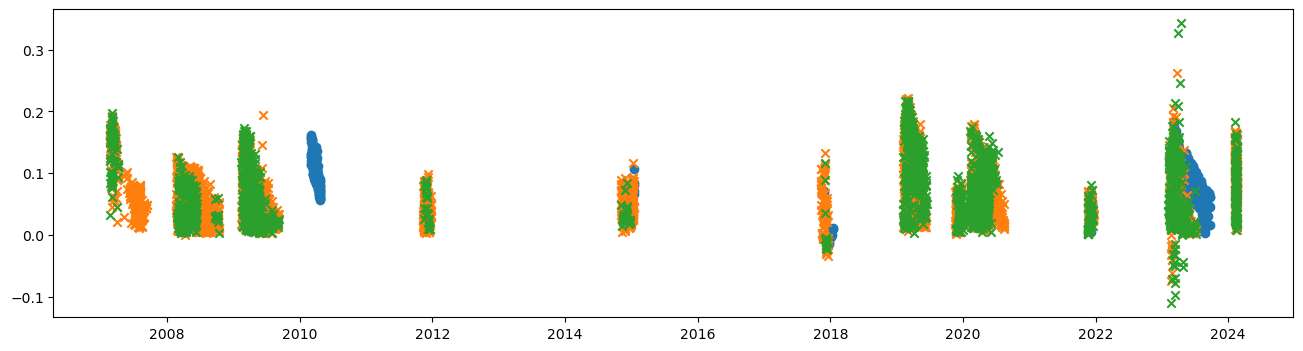

In [23]:
fig, ax = plt.subplots(figsize=(16,4))
img = ax.scatter(meop_1.df.index,meop_1.df.gph) 
img = ax.scatter(meop_2.df.index,meop_2.df.gph,marker='x')
img = ax.scatter(meop_3.df.index,meop_3.df.gph,marker='x') #,5,[1 for m in meop.df.latitude])#,5,[1 for m in meop.df.latitude])
 #,5,[1 for m in meop.df.latitude])#,5,[1 for m in meop.df.latitude])
#cbar = plt.colorbar(img)

In [24]:
# crop datasets to chosen area
extent = data_extent
sla_ = crop_to_extent(sla,extent)
sla0_ = crop_to_extent(sla0,extent)
lwe_ = crop_to_extent(lwe_ds,extent).lwe_thickness
dot_ = crop_to_extent(dot_ds,extent).dota
sha_sla_ = crop_to_extent(sha_ds_sla,extent).sha
sha_dot_ = crop_to_extent(sha_ds_dot,extent).sha
sice_ = crop_to_extent(sice,extent)

(12053.0, 18962.0)

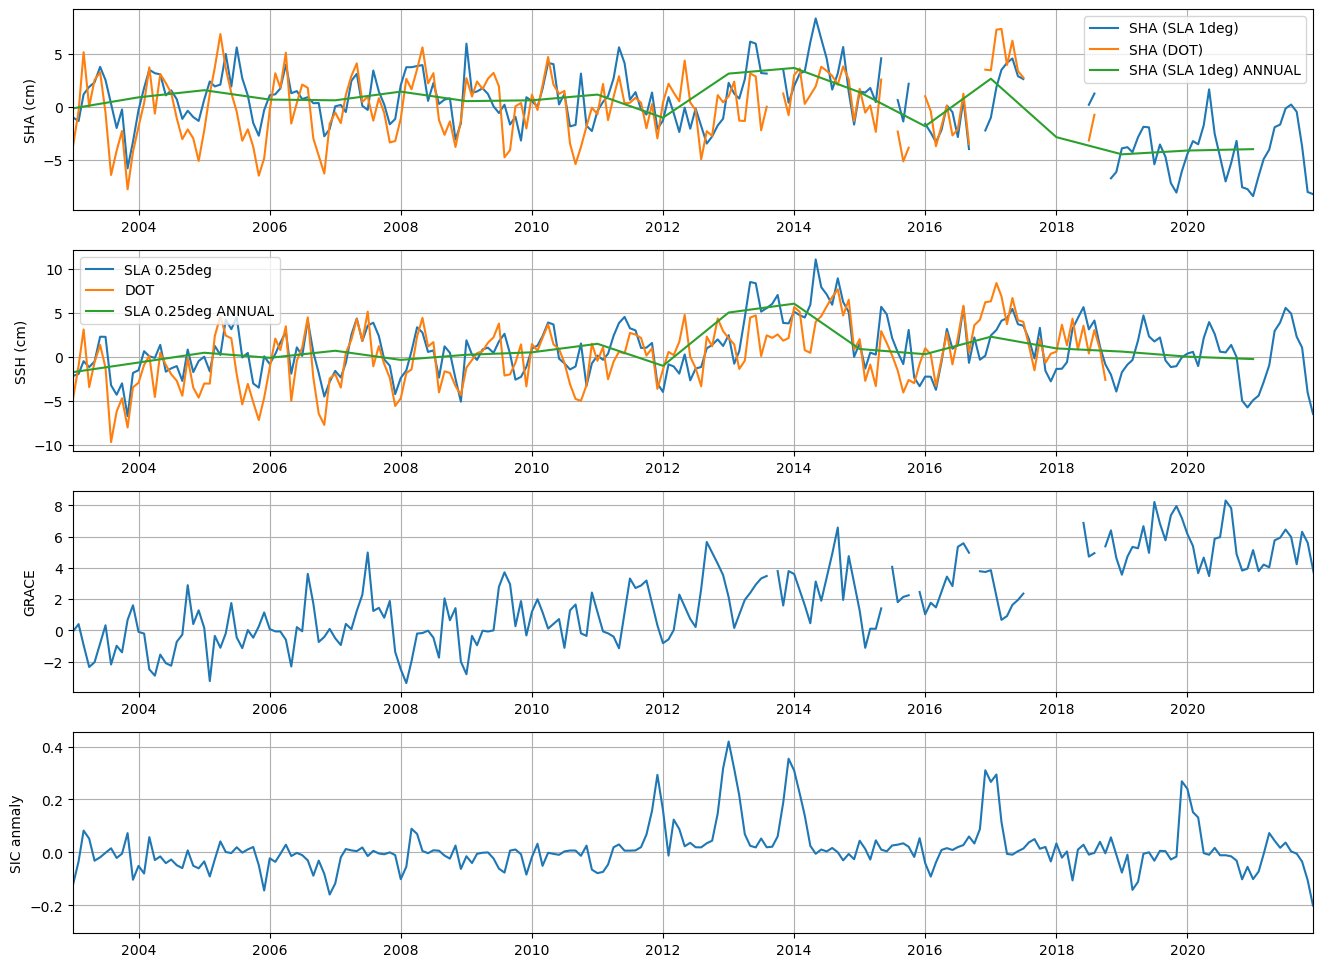

In [25]:
fig,ax = plt.subplots(4,1,figsize=(16,12))
ax[0].plot(sha_sla_.time,sha_sla_.mean(['latitude','longitude']),label='SHA (SLA 1deg)')
ax[0].plot(sha_dot_.time,sha_dot_.mean(['latitude','longitude']),label='SHA (DOT)')
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]
ax[0].plot(yr(sha_sla_),an(sha_sla_).mean(['latitude','longitude']),label='SHA (SLA 1deg) ANNUAL')
#ax[0].plot(yr(sha_dot_),an(sha_dot_).mean(['latitude','longitude']),label='SHA (DOT) ANNUAL')
ax[0].set_ylabel('SHA (cm)')
ax[0].legend(loc='best')
ax[0].grid()
ax[0].set_xlim([sla_.time[0],sla_.time[-1]])
# ax.scatter(meop.df.index,meop.df.gph*100,1,marker='x')
ax[1].plot(sla0_.time,sla0_.mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(dot_.time,dot_.mean(['latitude','longitude']),label='DOT')
ax[1].plot(yr(sla0_),an(sla0_).mean(['latitude','longitude']),label='SLA 0.25deg ANNUAL')
#ax[1].plot(yr(dot_),an(dot_).mean(['latitude','longitude']),label='DOT')
ax[1].set_ylabel('SSH (cm)')
ax[1].legend(loc='best')
ax[1].grid()
ax[1].set_xlim([sla_.time[0],sla_.time[-1]])

ax[2].plot(lwe_.time,lwe_.mean(['latitude','longitude']))
ax[2].set_ylabel('GRACE')
ax[2].grid()
ax[2].set_xlim([sla_.time[0],sla_.time[-1]])

sice_anom = sice_.groupby('time.month') - sice_.groupby('time.month').mean()
ax[3].plot(sice_.time,sice_anom.mean(['latitude','longitude']))
ax[3].set_ylabel('SIC anmaly')
ax[3].grid()
ax[3].set_xlim([sla_.time[0],sla_.time[-1]])



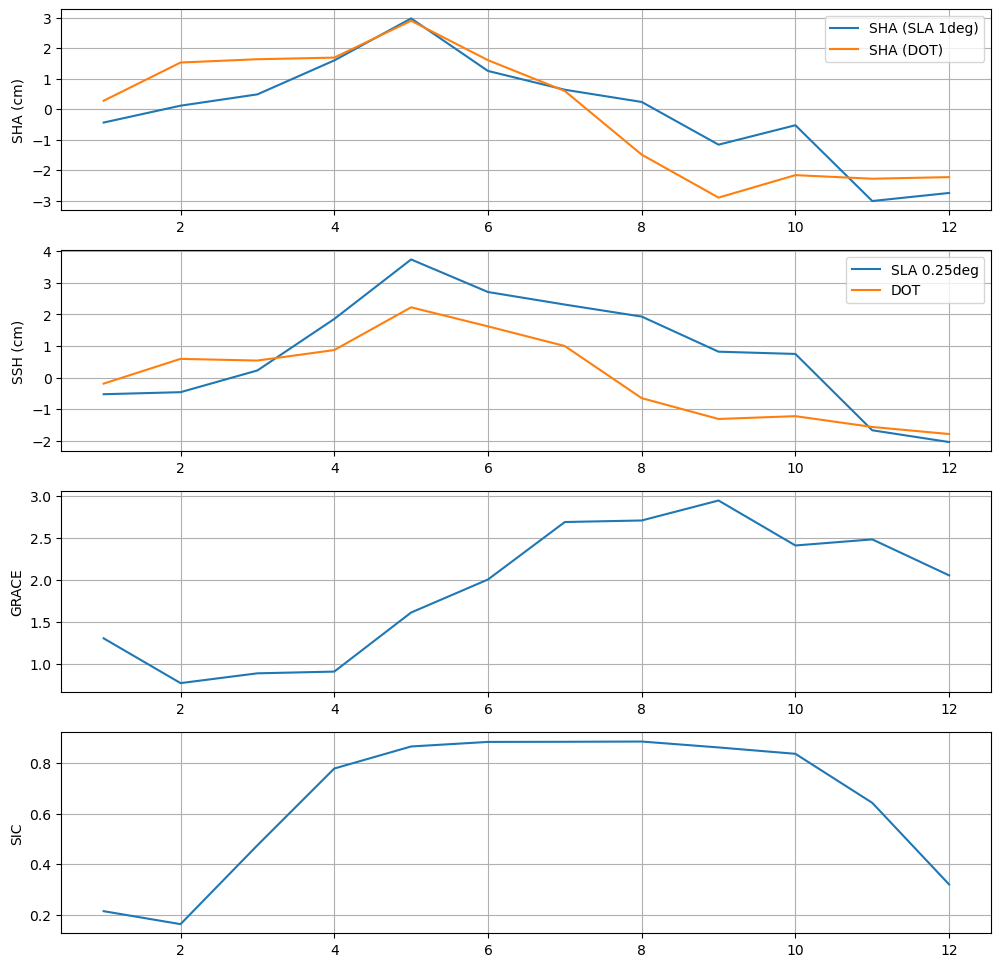

In [26]:
fig,ax = plt.subplots(4,1,figsize=(12,12))

cmt = lambda da: da.groupby('time.month').mean()
months = np.arange(12) + 1

ax[0].plot(months,cmt(sha_sla_).mean(['latitude','longitude']),label='SHA (SLA 1deg)')
ax[0].plot(months,cmt(sha_dot_).mean(['latitude','longitude']),label='SHA (DOT)')
ax[0].set_ylabel('SHA (cm)')
ax[0].legend(loc='best')
ax[0].grid()
# ax.scatter(meop.df.index,meop.df.gph*100,1,marker='x')
ax[1].plot(months,cmt(sla0_).mean(['latitude','longitude']),label='SLA 0.25deg')
ax[1].plot(months,cmt(dot_).mean(['latitude','longitude']),label='DOT')
ax[1].set_ylabel('SSH (cm)')
ax[1].legend(loc='best')
ax[1].grid()

ax[2].plot(months,cmt(lwe_).mean(['latitude','longitude']))
ax[2].set_ylabel('GRACE')
ax[2].grid()

ax[3].plot(months,cmt(sice_).mean(['latitude','longitude']))
ax[3].set_ylabel('SIC')
ax[3].grid()



In [27]:
years = set(sha_sla_.time.dt.year.to_numpy())

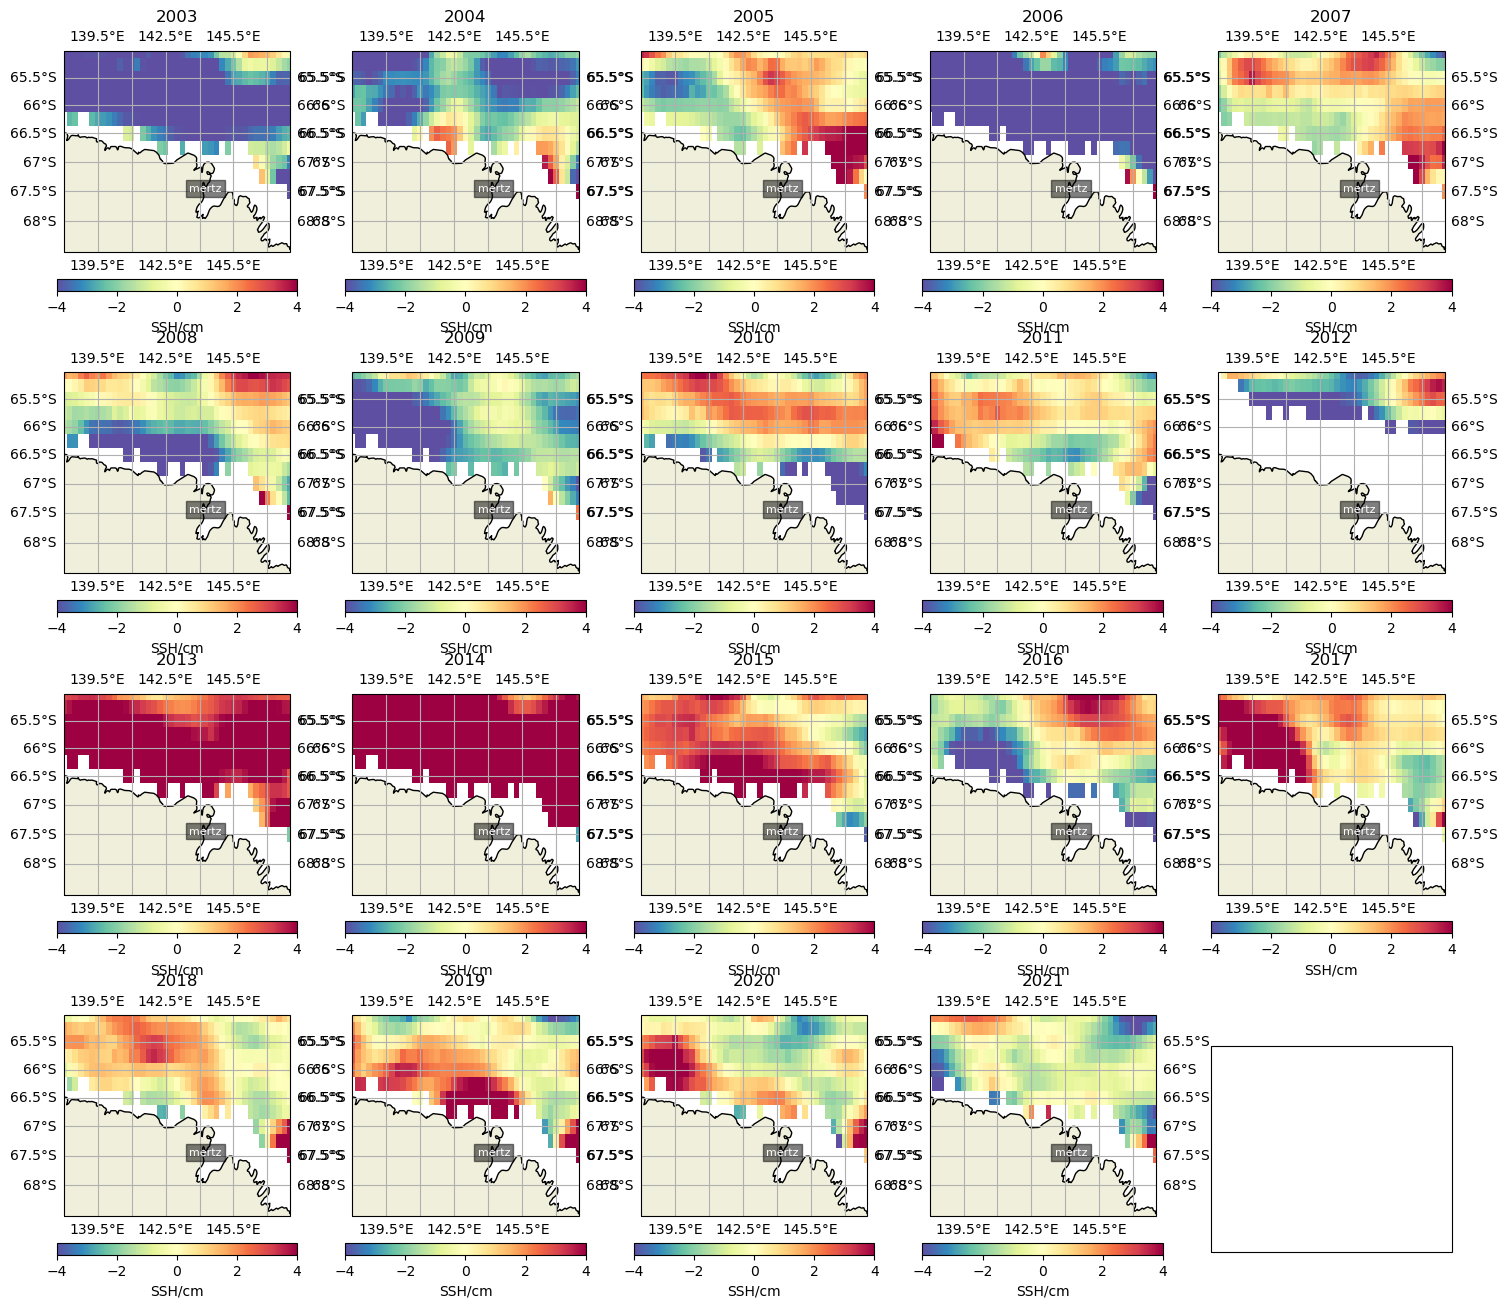

In [28]:
fig, ax = plt.subplots(4,int(np.ceil(len(years)/4)),figsize=(18,16), subplot_kw={"projection":ccrs.Mercator()})

pfsp = lambda ax, yr: pfns.sp(ax,seasonal_anomaly(sla0_).sel(time=slice(pd.Timestamp(yr,5,1),pd.Timestamp(yr,5,28))).mean('time'),title=yr,extent=map_extent,cbar="SSH/cm",vmax=4,cbar_orientation='horizontal',land_zorder=2)

ax=ax.flat
for i,y in enumerate(set(sla0_.time.dt.year.to_numpy())):
    # idx = (np.equal(years,y))
    # for profile in list(compress(profiles,idx)):
    #     ax[i].set_title(str(y))
    pfsp(ax[i],y)
    ax[i].text(mertz[0],mertz[1],'mertz',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))




IndexError: index 20 is out of bounds for axis 0 with size 20

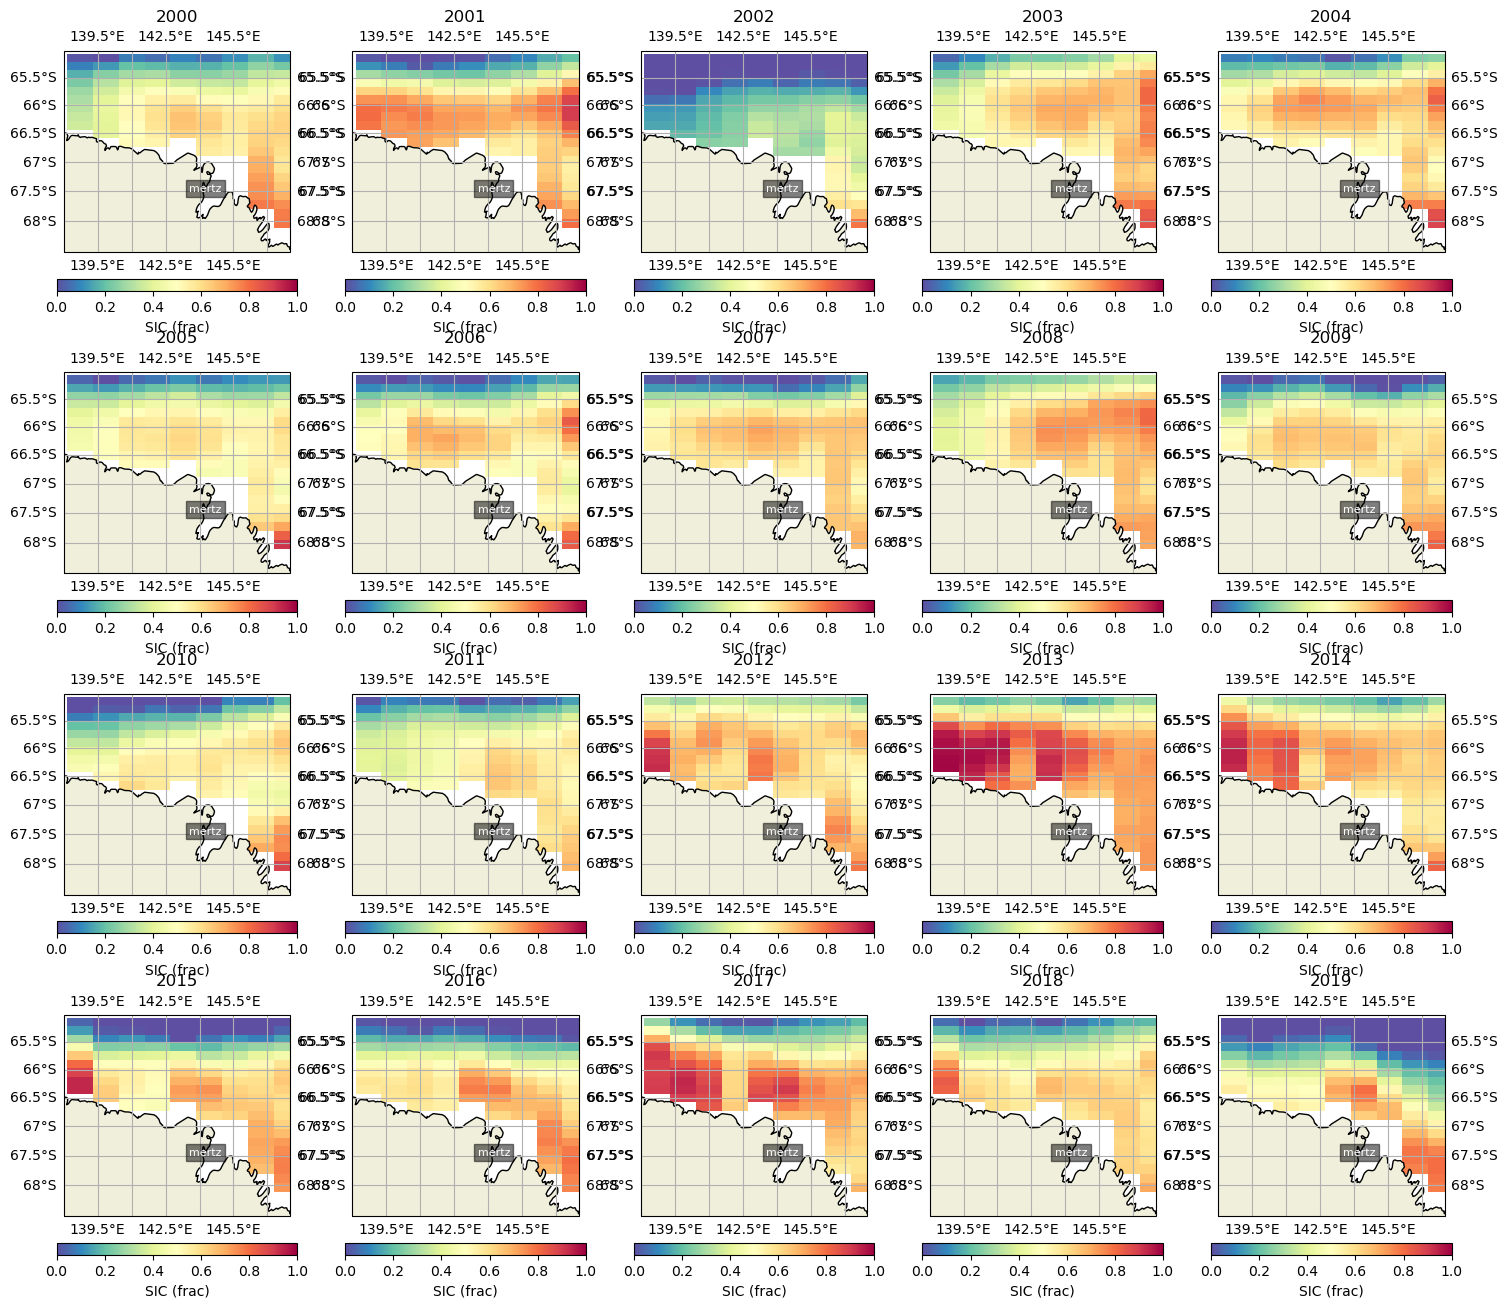

In [ ]:
fig, ax = plt.subplots(4,int(np.ceil(len(years)/4)),figsize=(18,16), subplot_kw={"projection":ccrs.Mercator()})

month = 3
pfsp = lambda ax, yr: pfns.sp(ax,sice_.sel(time=slice(pd.Timestamp(yr,month,1),pd.Timestamp(yr,month,28))).mean('time'),title=yr,extent=map_extent,cbar="SIC (frac)",vmin=0,vmax=1,cbar_orientation='horizontal',land_zorder=2)

ax=ax.flat
for i,y in enumerate(set(sla0_.time.dt.year.to_numpy())):
    # idx = (np.equal(years,y))
    # for profile in list(compress(profiles,idx)):
    #     ax[i].set_title(str(y))
    pfsp(ax[i],y)
    ax[i].text(mertz[0],mertz[1],'mertz',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))




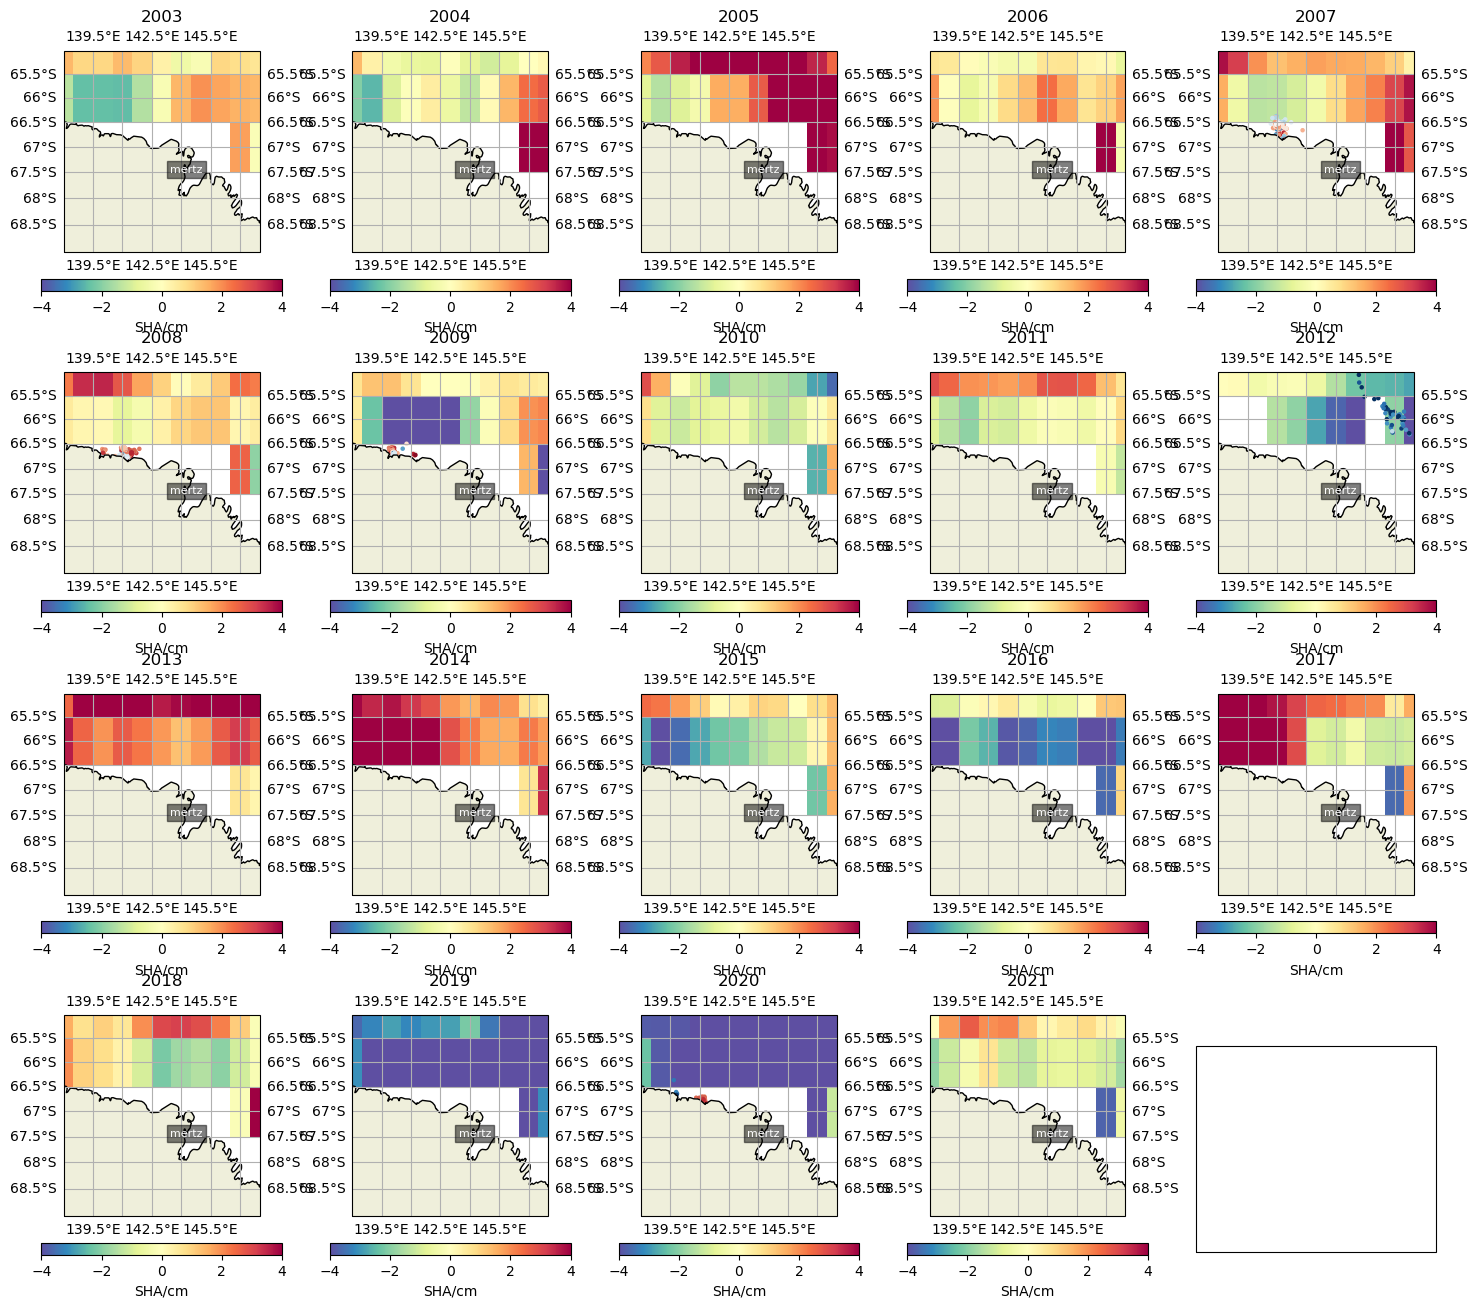

In [24]:
fig, ax = plt.subplots(4,int(np.ceil(len(years)/4)),figsize=(18,16), subplot_kw={"projection":ccrs.Mercator()})
pfsp = lambda ax, yr: pfns.sp(ax,sha_sla_.sel(time=slice(pd.Timestamp(yr,7,1),pd.Timestamp(yr,9,30))).mean('time'),title=yr,extent=map_extent,cbar="SHA/cm",vmax=4,cbar_orientation='horizontal',land_zorder=2)

ax=ax.flat
for i,y in enumerate(set(sha_sla_.time.dt.year.to_numpy())):
    # idx = (np.equal(years,y))
    # for profile in list(compress(profiles,idx)):
    #     ax[i].set_title(str(y))
    pfsp(ax[i],y)
    ax[i].text(mertz[0],mertz[1],'mertz',transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))

    df_y = meop.df[(meop.df.index.month > 6) & (meop.df.index.month < 10) & (meop.df.index.year==y)]
    ax[i].scatter(df_y.longitude,df_y.latitude,5,df_y.gph*100,vmax=10,vmin=0,cmap='RdBu',transform=ccrs.PlateCarree())



